In [1]:
!pip install -q --upgrade pip
!pip install -q pandas numpy matplotlib pyarrow lightgbm statsmodels scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.4 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
DRIVE_DIR = "/content/drive/MyDrive/energy-forecast"

RAW_BACKUP = Path(f"{DRIVE_DIR}/raw")
holiday_path = Path("/content/data/uk_bank_holidays.csv")

if not holiday_path.exists():
    !mkdir -p /content/data
    !cp -r "$RAW_BACKUP"/* /content/data/
    print("Restored raw dataset from Drive")

df = pd.read_parquet(f"{DRIVE_DIR}/aggregate_hourly.parquet")
print(df.shape)

holidays = pd.read_csv(holiday_path)
holiday_dates = set(pd.to_datetime(holidays.iloc[:, 0], errors="coerce").dt.date)
print(f"Bank holidays loaded: {len(holiday_dates)}")

Mounted at /content/drive
Restored raw dataset from Drive
(19864, 10)
Bank holidays loaded: 25


In [7]:
df = df[(df["hour"] >= "2013-01-01") & (df["hour"] < "2014-03-01")].copy()
df = df.sort_values("hour").reset_index(drop=True)
print(df.shape, "|", df["hour"].min(), "→", df["hour"].max())
print("Demand NaNs:", int(df["demand"].isna().sum()))
df = df.dropna(subset=["demand"]).reset_index(drop=True)

(10153, 10) | 2013-01-01 00:00:00+00:00 → 2014-02-28 00:00:00+00:00
Demand NaNs: 0


In [8]:
def build_features(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    out["hour_of_day"] = out["hour"].dt.hour
    out["dow"] = out["hour"].dt.dayofweek
    out["month"] = out["hour"].dt.month
    out["is_weekend"] = (out["dow"] >= 5).astype(int)
    out["is_holiday"] = out["hour"].dt.date.isin(holiday_dates).astype(int)

    for lag in [1, 2, 3, 24, 48, 72, 168]:
        out[f"lag_{lag}"] = out["demand"].shift(lag)

    shifted = out["demand"].shift(1)
    out["roll_24_mean"] = shifted.rolling(24).mean()
    out["roll_24_std"] = shifted.rolling(24).std()
    out["roll_168_mean"] = shifted.rolling(168).mean()

    return out

FEATURES = [
    "hour_of_day", "dow", "month", "is_weekend", "is_holiday",
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_72", "lag_168",
    "roll_24_mean", "roll_24_std", "roll_168_mean",
    "temperature", "apparentTemperature", "humidity", "windSpeed",
]

feat = build_features(df).dropna().reset_index(drop=True)
print(feat.shape, "| rows lost to lag/rolling warmup:", len(df) - len(feat))

(9983, 25) | rows lost to lag/rolling warmup: 170


In [9]:
train = feat[feat["hour"] < "2013-11-01"]
val = feat[(feat["hour"] >= "2013-11-01") & (feat["hour"] < "2014-01-01")]
test = feat[feat["hour"] >= "2014-01-01"]

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6s} {part['hour'].min()}  →  {part['hour'].max()}  ({len(part):,} rows)")

train  2013-01-08 00:00:00+00:00  →  2013-10-31 23:00:00+00:00  (7,126 rows)
val    2013-11-01 00:00:00+00:00  →  2013-12-31 23:00:00+00:00  (1,464 rows)
test   2014-01-01 00:00:00+00:00  →  2014-02-28 00:00:00+00:00  (1,393 rows)


In [10]:
def mae(y, p):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))

def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

def smape(y, p):
    y, p = np.asarray(y, dtype=float), np.asarray(p, dtype=float)
    denom = np.abs(y) + np.abs(p)
    return float(np.mean(np.where(denom == 0, 0.0, 2 * np.abs(y - p) / denom)) * 100)

results = []
def record(model_name: str, y_true, y_pred, split: str = "test"):
    results.append({
        "model": model_name,
        "split": split,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE%": smape(y_true, y_pred),
    })
    print(f"{model_name:22s} [{split}]  MAE {results[-1]['MAE']:.4f}  RMSE {results[-1]['RMSE']:.4f}  sMAPE {results[-1]['sMAPE%']:.2f}%")

In [11]:
record("seasonal_naive_168h", test["demand"], test["lag_168"])

seasonal_naive_168h    [test]  MAE 0.0243  RMSE 0.0372  sMAPE 5.05%


In [14]:
from statsmodels.tsa.api import ExponentialSmoothing

# Set frequency and interpolate the 2 NaNs to prevent NaN propagation in statsmodels
hw_train = pd.concat([train, val]).set_index("hour")["demand"].asfreq("h").interpolate(method="linear")
print("NaNs in HW train series:", int(hw_train.isna().sum()))

hw = ExponentialSmoothing(
    hw_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24,
    initialization_method="estimated",
).fit(optimized=True, use_brute=True)

hw_pred = pd.Series(hw.forecast(len(test)).values, index=pd.DatetimeIndex(test["hour"].values))

if hw_pred.isna().any():
    print(f"Holt-Winters produced {int(hw_pred.isna().sum())} NaNs — retrying without trend component")
    hw = ExponentialSmoothing(
        hw_train,
        trend=None,
        seasonal="add",
        seasonal_periods=24,
        initialization_method="estimated",
    ).fit(optimized=True, use_brute=True)
    hw_pred = pd.Series(hw.forecast(len(test)).values, index=pd.DatetimeIndex(test["hour"].values))

assert not hw_pred.isna().any(), "Holt-Winters still producing NaNs"
record("holt_winters_24", test["demand"], hw_pred.values)

NaNs in HW train series: 0
holt_winters_24        [test]  MAE 0.0518  RMSE 0.0661  sMAPE 11.76%


In [15]:
import lightgbm as lgb

dtrain = lgb.Dataset(train[FEATURES], label=train["demand"])
dval = lgb.Dataset(val[FEATURES], label=val["demand"], reference=dtrain)

params = {
    "objective": "regression",
    "metric": "l2",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 1,
    "seed": 42,
    "verbose": -1,
}

gbm = lgb.train(
    params,
    dtrain,
    num_boost_round=3000,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
print(f"Best iteration: {gbm.best_iteration}")

lgb_pred = gbm.predict(test[FEATURES], num_iteration=gbm.best_iteration)
record("lightgbm", test["demand"], lgb_pred)

Best iteration: 468
lightgbm               [test]  MAE 0.0111  RMSE 0.0158  sMAPE 2.38%


In [16]:
comp = pd.DataFrame(results)
base_mae = comp.loc[comp["model"] == "seasonal_naive_168h", "MAE"].iloc[0]
comp["MAE_vs_naive"] = ((comp["MAE"] - base_mae) / base_mae * 100).round(1).astype(str) + "%"
print(comp.to_string(index=False))

              model split      MAE     RMSE    sMAPE% MAE_vs_naive
seasonal_naive_168h  test 0.024286 0.037218  5.046515         0.0%
    holt_winters_24  test 0.051804 0.066126 11.758055       113.3%
           lightgbm  test 0.011134 0.015763  2.381427       -54.2%


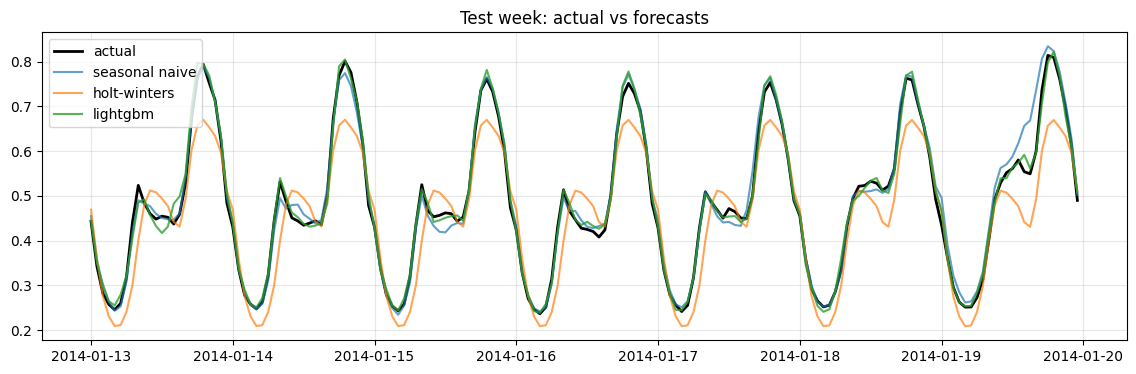

In [17]:
import matplotlib.pyplot as plt

week = test[(test["hour"] >= "2014-01-13") & (test["hour"] < "2014-01-20")]
plt.figure(figsize=(14, 4))
plt.plot(week["hour"], week["demand"], label="actual", lw=2, color="black")
plt.plot(week["hour"], week["lag_168"], label="seasonal naive", alpha=0.7)
plt.plot(week["hour"], hw_pred.loc[week["hour"].values], label="holt-winters", alpha=0.7)
plt.plot(week["hour"], gbm.predict(week[FEATURES], num_iteration=gbm.best_iteration), label="lightgbm", alpha=0.8)
plt.legend()
plt.title("Test week: actual vs forecasts")
plt.grid(alpha=0.3)
plt.show()

In [18]:
import json

gbm.save_model(f"{DRIVE_DIR}/lightgbm_demand.txt")
feat.to_parquet(f"{DRIVE_DIR}/features_hourly.parquet", index=False)
with open(f"{DRIVE_DIR}/phase3_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved to Drive:")
print(" - lightgbm_demand.txt")
print(" - features_hourly.parquet")
print(" - phase3_results.json")

Saved to Drive:
 - lightgbm_demand.txt
 - features_hourly.parquet
 - phase3_results.json
